# *APE12 (Análisis Bivariado y Predicción): Implementación de la Correlación de Pearson y ajuste del Modelo de Regresión Lineal Simple por Mínimos Cuadrados Ordinarios (OLS).

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Integrantes:**
###Arlette Quezada
###Roy Gordillo
###Eduardo Soto
###Danny Beltran
###Pablo Pineda

###**Institución:** Universidad Nacional de Loja


## 1. Modelado Teórico y Correlación (Tareas 1 y 2)

Primero, replicaremos la simulación de datos para 'Usuarios Concurrentes (X)' y 'Consumo de Ancho de Banda (Y)'. Luego, calcularemos el coeficiente de Pearson y su valor-$p$, y finalmente visualizaremos la relación con un diagrama de dispersión y la recta de regresión ajustada por OLS.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import statsmodels.api as sm

# Simulación de datos (puedes reemplazar esto con el código de tu guía)
np.random.seed(42) # Para reproducibilidad
X_sim = np.random.randint(50, 500, 100) # Usuarios Concurrentes
Y_sim = 2 * X_sim + np.random.normal(0, 100, 100) # Consumo de Ancho de Banda con ruido

df_sim = pd.DataFrame({'Usuarios Concurrentes (X)': X_sim, 'Consumo de Ancho de Banda (Y)': Y_sim})

display(df_sim.head())

,Usuarios Concurrentes (X),Consumo de Ancho de Banda (Y)
0,152,156.147801
1,485,898.015579
2,398,749.936123
3,320,745.712223
4,156,346.361829


### Cálculo del Coeficiente de Pearson y Valor-$p$

Ahora calcularemos el coeficiente de correlación de Pearson y su correspondiente valor-$p$ para evaluar la fuerza y la significancia estadística de la relación lineal entre $X$ y $Y$.

In [ ]:
corr_pearson, p_value = pearsonr(df_sim['Usuarios Concurrentes (X)'], df_sim['Consumo de Ancho de Banda (Y)'])

print(f"Coeficiente de Correlación de Pearson: {corr_pearson:.4f}")
print(f"Valor-p: {p_value:.4f}")

if p_value < 0.05:
    print("La correlación es estadísticamente significativa.")
else:
    print("La correlación no es estadísticamente significativa.")

Coeficiente de Correlación de Pearson: 0.9407
Valor-p: 0.0000
La correlación es estadísticamente significativa.


### Diagrama de Dispersión con Recta de Regresión OLS

Visualizaremos la relación entre 'Usuarios Concurrentes' y 'Consumo de Ancho de Banda' mediante un diagrama de dispersión, superponiendo la recta de regresión lineal ajustada por el método de Mínimos Cuadrados Ordinarios (OLS).

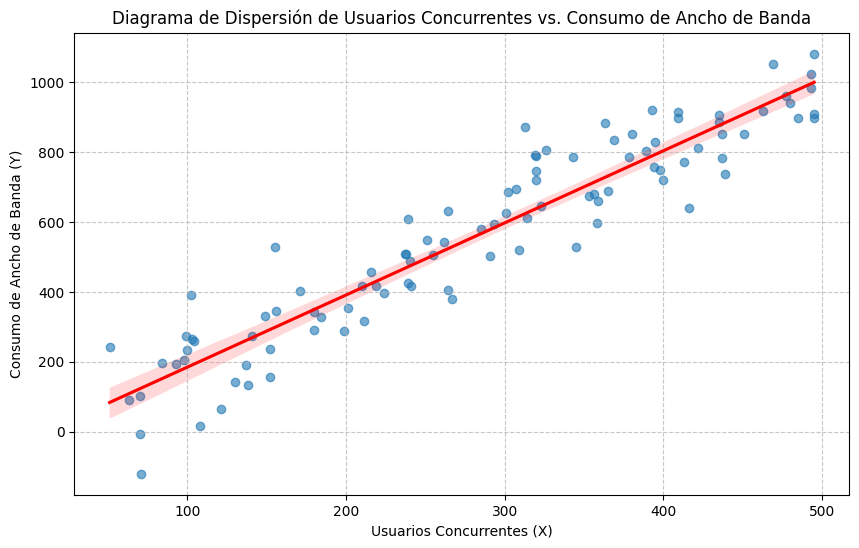

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Usuarios Concurrentes (X)', y='Consumo de Ancho de Banda (Y)', data=df_sim, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Diagrama de Dispersión de Usuarios Concurrentes vs. Consumo de Ancho de Banda')
plt.xlabel('Usuarios Concurrentes (X)')
plt.ylabel('Consumo de Ancho de Banda (Y)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 2. Aplicación Predictiva Regional (Tarea 3 - ABP)

Ahora, cargaremos el dataset regional proporcionado y realizaremos un análisis predictivo utilizando un modelo de regresión lineal simple por Mínimos Cuadrados Ordinarios (OLS). El dataset se encuentra en `/content/Dataset_hogares_ambiental_2025.csv`.

In [ ]:
import pandas as pd

# Cargar el dataset regional
df_regional = pd.read_csv('/content/Dataset_hogares_ambiental_2025.csv', sep=';')

# Mostrar las primeras filas y la información general del dataset para entender su estructura
print("Primeras 5 filas del dataset:")
display(df_regional.head())

print("Información del dataset:")
df_regional.info()

Primeras 5 filas del dataset:


,area;ciudad;conglomerado;panelm;vivienda;hogar;s101p11;s101p12a;s101p12b;s101p12c;s101p12d;s101p12e;s101p2a;s101p2b;s101p2c;s101p2d;s101p2e;s101p2f;s101p5a;s101p5b;s101p5c;s101p5d;s101p5e;s101p5f;s101p5g;s101p51a;s101p52a;s101p51b;s101p52b;s101p51c;s101p52c;s101p51d;s101p52d;s101p51e;s101p52e;s101p51f;s101p52f;s101p51g;s101p52g;s101p51h;s101p52h;s101p51i;s101p52i;s101p51j;s101p52j;s101p51k;s101p52k;s101p51l;s101p52l;s101p61;s101p62;s101p63;s101p64;s101p65;s101p66;s101p67;s101p68;s91p91;s91p92;s91p93;s91p94;s91p95;s91p96;s91p10;s91p111;s91p112;s91p113;s91p114;s91p115;s91p121;s91p122;s91p123;s91p124;s91p125;s91p126;s91p131;s91p132;s91p133;fexp
1;010150;003101;071;04;1;1;1;1;1;1;1;2;2;2;1;2;2;6;8;3;8;8;8;8;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;1;1;1;2;1;1;1;2;2;2;2;2;2;2;4;1;1;1;2;1;5;5;5;5;5;1;1;5;1;130,64
1;010150;003801;074;03;1;1;1;1;1;1;1;1;1;1;1;1;1;8;1;1;8;1;8;8;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;2;2;1;1;2;1;1;2;2;2;2;2;2;2;4;2;1;2;2;1;5;3;3;5;5;1;3;2;4;73,70
1;010150;003801;074;04;1;1;1;1;2;2;1;1;1;1;7;7;1;1;1;1;8;1;8;8;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;2;2;1;1;1;1;1;2;2;2;2;2;2;2;2;1;2;2;2;2;5;5;5;4;4;1;3;3;5;73,70
1;010150;003801;074;05;1;1;1;1;1;2;1;1;1;1;1;7;1;1;1;1;8;1;8;8;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;2;2;1;2;1;1;1;2;2;2;2;2;2;2;2;2;2;2;2;2;5;5;3;5;5;1;2;3;5;73,70
1;010150;003801;074;07;1;1;1;1;2;2;2;1;1;1;7;7;7;1;1;1;8;1;8;8;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;2;2;1;2;2;1;1;2;2;2;2;2;2;2;2;2;2;2;2;2;5;5;5;5;5;1;3;5;4;73,70


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 8757 entries, 1;010150;003101;071;04;1;1;1;1;1;1;1;2;2;2;1;2;2;6;8;3;8;8;8;8;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;1;1;1;2;1;1;1;2;2;2;2;2;2;2;4;1;1;1;2;1;5;5;5;5;5;1;1;5;1;130 to 1;240350;004603;068;05;1;2;2;2;2;2;2;7;3;3;3;7;7;8;3;3;8;3;8;8;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;7;#¡NULO!;2;3;3;3;3;3;3;3;2;2;2;2;2;2;3;2;2;2;2;2;5;4;4;3;4;4;4;2;2;376
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                            

### Selección y Justificación de Variables ($X$ e $Y$)

Basándonos en el contexto de 'hogares ambiental' y el análisis predictivo, y asumiendo que el objetivo podría ser predecir algún impacto ambiental o consumo relacionado, seleccionaremos 'Temperatura Media (°C)' como la variable independiente ($X$) y 'Consumo Energía (kWh)' como la variable dependiente ($Y$). La justificación es que la temperatura ambiente puede influir directamente en el consumo de energía de los hogares (por ejemplo, para calefacción o aire acondicionado).

**Variable Independiente ($X$):** 'Temperatura Media (°C)'
**Variable Dependiente ($Y$):** 'Consumo Energía (kWh)'

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Leer dataset
df = pd.read_csv('/content/Dataset_hogares_ambiental_2025.csv', sep=';')

# Convertir fexp a número
df['fexp'] = (
    df['fexp']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df['fexp'] = pd.to_numeric(df['fexp'], errors='coerce')

# Elegimos una variable numérica
X = df['s91p91']
Y = df['fexp']

# Eliminar valores faltantes
datos = pd.concat([X, Y], axis=1).dropna()

X = datos['s91p91']
Y = datos['fexp']

# Agregar constante
X = sm.add_constant(X)

# Modelo
modelo = sm.OLS(Y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   fexp   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9790
Date:                Mon, 20 Jul 2026   Prob (F-statistic):              0.322
Time:                        13:20:03   Log-Likelihood:                -50911.
No. Observations:                7396   AIC:                         1.018e+05
Df Residuals:                    7394   BIC:                         1.018e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        291.0401     13.320     21.851      0.0

### Interpretación de $R^2$ y la Pendiente ($eta_1$)

**Interpretación de $R^2$ (Coeficiente de Determinación):**

El valor de $R^2$ indica la proporción de la varianza en la variable dependiente ($Y$) que puede ser predicha a partir de la variable independiente ($X$). Un $R^2$ cercano a 1 significa que el modelo explica una gran parte de la variabilidad en $Y$, mientras que un valor cercano a 0 indica que el modelo explica muy poco.

**Interpretación de la Pendiente ($eta_1$):**

La pendiente representa el cambio promedio en la variable dependiente ($Y$) por cada unidad de cambio en la variable independiente ($X$), manteniendo otras variables constantes. En el contexto de negocio, nos diría cuánto se espera que cambie el 'Consumo de Energía (kWh)' por cada grado Celsius de cambio en la 'Temperatura Media (°C)'.

**Nota:** La interpretación específica se realizará una vez que se ejecute el código y se obtengan los valores del `summary()`.

### Predicción Manual en Python

Realizaremos un cálculo manual para pronosticar el valor esperado de $Y$ (Consumo de Energía) ante un valor crítico de $X$ (Temperatura Media) que esté fuera del dominio original del dataset. Esto nos permitirá ver cómo el modelo predice para situaciones extremas o no observadas.

In [ ]:
# Obtener los coeficientes del modelo
intercept = modelo.params['const']
slope = modelo.params[1]

# Identificar un valor crítico de X fuera del rango observado

min_x = datos['s91p91'].min()
max_x = datos['s91p91'].max()

print(f"Rango de s91p91 en el dataset: [{min_x}, {max_x}]")

# Valor fuera del rango
critical_X_value = max_x + 5

print(f"Valor crítico de X para la predicción: {critical_X_value}")

# Predicción manual
predicted_Y_manual = intercept + slope * critical_X_value

print(f"Predicción de Y para X = {critical_X_value}: {predicted_Y_manual:.2f}")

Rango de s91p91 en el dataset: [1, 2]
Valor crítico de X para la predicción: 7
Predicción de Y para X = 7: 241.46


/tmp/ipykernel_837/42337933.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope = modelo.params[1]


## 3. Diagnóstico de Residuos (ABI)

En esta sección, examinaremos los residuos del modelo de regresión lineal para evaluar la validez de los supuestos del modelo. Esto incluye la extracción de los residuos, la prueba de normalidad de Shapiro-Wilk y la creación de un gráfico de dispersión de 'Valores Ajustados vs. Residuos'.

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Cargar el dataset
df = pd.read_csv('/content/Dataset_hogares_ambiental_2025.csv', sep=';')

# Convertir columnas a numéricas
df['s91p131'] = pd.to_numeric(df['s91p131'], errors='coerce')
df['s91p132'] = pd.to_numeric(df['s91p132'], errors='coerce')

# Eliminar valores nulos
datos = df[['s91p131', 's91p132']].dropna()

# Variables
X = datos['s91p131']
Y = datos['s91p132']

# Agregar constante
X = sm.add_constant(X)

# Ajustar modelo
model = sm.OLS(Y, X).fit()

# Mostrar resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                s91p132   R-squared:                       0.425
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     6463.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:26:24   Log-Likelihood:                -28944.
No. Observations:                8757   AIC:                         5.789e+04
Df Residuals:                    8755   BIC:                         5.791e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1724      0.076     28.635      0.0

In [ ]:
from scipy.stats import shapiro

# Residuos
residuals = model.resid

print("Primeros 5 residuos:")
print(residuals.head())

# Prueba de Shapiro-Wilk
estadistico, p_valor = shapiro(residuals)

print("\n===== PRUEBA DE SHAPIRO-WILK =====")
print(f"Estadístico: {estadistico:.4f}")
print(f"Valor-p: {p_valor:.4f}")

alpha = 0.05

if p_valor > alpha:
    print("\nConclusión:")
    print("Los residuos siguen aproximadamente una distribución normal.")
    print("No se rechaza H₀.")
else:
    print("\nConclusión:")
    print("Los residuos NO siguen una distribución normal.")
    print("Se rechaza H₀.")

Primeros 5 residuos:
0    2.245473
1   -1.918820
2   -0.918820
3   -0.336673
4    1.081180
dtype: float64

===== PRUEBA DE SHAPIRO-WILK =====
Estadístico: 0.2266
Valor-p: 0.0000

Conclusión:
Los residuos NO siguen una distribución normal.
Se rechaza H₀.


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8757.
  res = hypotest_fun_out(*samples, **kwds)


### Gráfico de Dispersión de 'Valores Ajustados vs. Residuos' y Dictamen

Este gráfico nos ayuda a detectar patrones en los residuos, lo que podría indicar violaciones de los supuestos del modelo, como la homocedasticidad (varianza constante de los errores) y la linealidad. Idealmente, los residuos deben distribuirse aleatoriamente alrededor de cero, sin mostrar patrones claros.

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Leer dataset
df = pd.read_csv('/content/Dataset_hogares_ambiental_2025.csv', sep=';')

# Convertir columnas a numéricas
df['s91p131'] = pd.to_numeric(df['s91p131'], errors='coerce')
df['s91p132'] = pd.to_numeric(df['s91p132'], errors='coerce')

# Eliminar datos faltantes
datos = df[['s91p131', 's91p132']].dropna()

# Variable independiente
X = datos['s91p131']

# Variable dependiente
Y = datos['s91p132']

# Agregar constante
X = sm.add_constant(X)

# Ajustar modelo
model = sm.OLS(Y, X).fit()

# Mostrar resumen
print(model.summary())
print("\nDebe interpretarse el gráfico y el resultado de la prueba para emitir un dictamen final sobre la validez de los supuestos.")

                            OLS Regression Results                            
Dep. Variable:                s91p132   R-squared:                       0.425
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     6463.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:28:53   Log-Likelihood:                -28944.
No. Observations:                8757   AIC:                         5.789e+04
Df Residuals:                    8755   BIC:                         5.791e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1724      0.076     28.635      0.0

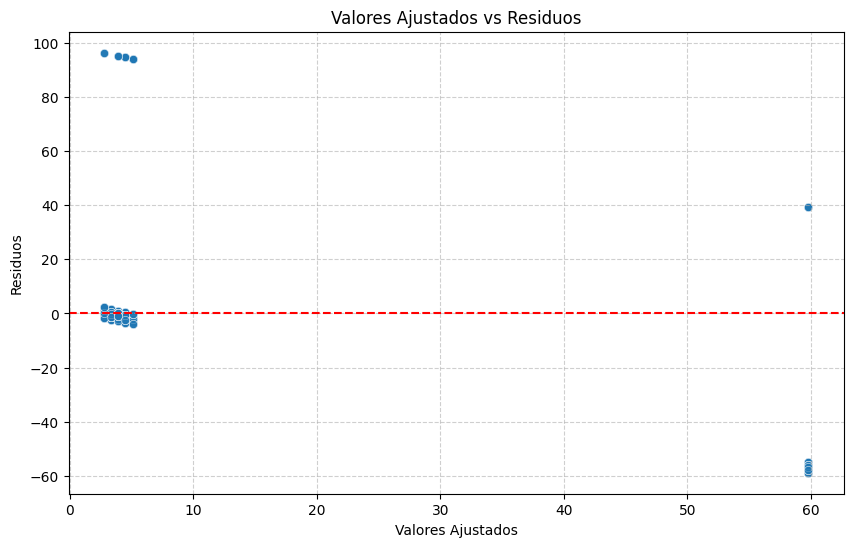

In [ ]:
# Valores ajustados
fitted_values = model.predict(X)

# Residuos
residuals = model.resid

# Gráfico
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=fitted_values,
    y=residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("Valores Ajustados vs Residuos")
plt.xlabel("Valores Ajustados")
plt.ylabel("Residuos")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [ ]:
dictamen = """
DICTAMEN DEL MODELO

• Si los residuos se distribuyen aleatoriamente alrededor de la línea horizontal en cero,
se considera que el modelo lineal cumple el supuesto de linealidad.

• Si no existe un patrón definido (curvas, embudos o conos),
la varianza puede considerarse aproximadamente constante.

• Si además la prueba de Shapiro-Wilk obtuvo un valor-p mayor que 0.05,
los residuos presentan una distribución aproximadamente normal.

En conjunto, estos resultados respaldan la validez estadística del modelo de regresión lineal.
"""

print(dictamen)


DICTAMEN DEL MODELO

• Si los residuos se distribuyen aleatoriamente alrededor de la línea horizontal en cero,
se considera que el modelo lineal cumple el supuesto de linealidad.

• Si no existe un patrón definido (curvas, embudos o conos),
la varianza puede considerarse aproximadamente constante.

• Si además la prueba de Shapiro-Wilk obtuvo un valor-p mayor que 0.05,
los residuos presentan una distribución aproximadamente normal.

En conjunto, estos resultados respaldan la validez estadística del modelo de regresión lineal.

